In [12]:
from pathlib import Path
from ultralytics import YOLO

In [2]:

yolo_root = Path("data/stenosis_yolo")

for split in ["train", "val", "test"]:
    image_dir = yolo_root / "images" / split
    label_dir = yolo_root / "labels" / split

    images = list(image_dir.glob("*.png"))
    labels = list(label_dir.glob("*.txt"))

    print(f"{split}:")
    print("  Images:", len(images))
    print("  Labels:", len(labels))

train:
  Images: 1000
  Labels: 1000
val:
  Images: 200
  Labels: 200
test:
  Images: 300
  Labels: 300


In [3]:
label = list(
    (yolo_root / "labels" / "train").glob("*.txt")
)

print("Number of label files:", len(label))

with open(label[0], "r") as f:
    print(f.read())

Number of label files: 1000
0 0.75830078125 0.591796875 0.7529296875 0.60791015625 0.7470703125 0.62548828125 0.74072265625 0.64501953125 0.732421875 0.66259765625 0.7197265625 0.68505859375 0.70947265625 0.70458984375 0.701171875 0.720703125 0.69140625 0.736328125 0.67919921875 0.75390625 0.669921875 0.7734375 0.65966796875 0.794921875 0.6484375 0.8173828125 0.6416015625 0.83740234375 0.6416015625 0.85498046875 0.66943359375 0.84814453125 0.66552734375 0.84130859375 0.66650390625 0.83154296875 0.67724609375 0.8154296875 0.68701171875 0.80078125 0.69970703125 0.78271484375 0.7080078125 0.767578125 0.7197265625 0.74853515625 0.73046875 0.72802734375 0.74267578125 0.71142578125 0.75 0.697265625 0.75830078125 0.68017578125 0.7685546875 0.65771484375 0.77685546875 0.64111328125 0.7861328125 0.62255859375 0.79150390625 0.60595703125 0.79541015625 0.5888671875 0.76220703125 0.580078125



In [4]:
model = YOLO("yolov8n-seg.pt")

In [5]:
from ultralytics import YOLO
import torch

print("PyTorch:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
print("GPU:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "CPU")

model = YOLO("yolov8n-seg.pt")

print("YOLOv8-seg model loaded successfully!")

PyTorch: 2.14.0+cu126
CUDA available: True
GPU: NVIDIA GeForce RTX 3050
YOLOv8-seg model loaded successfully!


In [6]:
model.train(
    data="data/stenosis_yolo/data.yaml",
    epochs=50,
    imgsz=512,
    batch=2,
    device=0,
    workers=0,
    resume=True
)

WARNING model 'yolov8n-seg.pt' is not a resumable training checkpoint (missing epoch/optimizer state). Use 'resume' only to continue incomplete training. Starting new training instead.
Ultralytics 8.4.158  Python-3.13.13 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=2, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data/stenosis_yolo/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=512, iou=0.7, keras=False, kobj=1.0, line_

ultralytics.utils.metrics.SegmentMetrics object with attributes:

ap_class_index: array([0])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x000001F6A40A4520>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)', 'Precision-Recall(M)', 'F1-Confidence(M)', 'Precision-Confidence(M)', 'Recall-Confidence(M)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.0410

In [1]:
from ultralytics import YOLO

model = YOLO("runs/segment/train-2/weights/best.pt")

metrics = model.val(
    data="data/stenosis_yolo/data.yaml",
    imgsz=512,
    batch=2,
    device=0
)

Ultralytics 8.4.158  Python-3.13.13 torch-2.14.0+cu126 CUDA:0 (NVIDIA GeForce RTX 3050, 6144MiB)
YOLOv8n-seg summary (fused): 85 layers, 3,258,259 parameters, 0 gradients, 11.3 GFLOPs
val: Fast image access  (ping: 0.10.0 ms, read: 120.527.7 MB/s, size: 110.3 KB)
val: Scanning C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\labels\val.cache... 200 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 200/200 36.5Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95)     Mask(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 100/100 3.3it/s 30.7s0.1s4
                   all        200        406      0.347       0.36      0.268      0.101      0.388      0.416      0.326      0.113
Speed: 1.6ms preprocess, 11.2ms inference, 0.0ms loss, 2.9ms postprocess per image
Results saved to C:\Users\homsokhim\PycharmProjects\Health_analysis\runs\segment\val


In [2]:
model.predict(
    source="data/stenosis_yolo/images/test",
    imgsz=512,
    device=0,
    save=True,
    save_txt=True
)


image 1/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\1.png: 512x512 (no detections), 44.0ms
image 2/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\10.png: 512x512 (no detections), 45.7ms
image 3/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\100.png: 512x512 1 stenosis, 14.5ms
image 4/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\101.png: 512x512 2 stenosiss, 14.9ms
image 5/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\102.png: 512x512 2 stenosiss, 15.7ms
image 6/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\103.png: 512x512 2 stenosiss, 13.9ms
image 7/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\104.png: 512x512 3 stenosiss, 17.5ms
image 8/300 C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_y

[ultralytics.engine.results.Results object with attributes:
 
 boxes: ultralytics.engine.results.Boxes object
 depth: None
 keypoints: None
 masks: None
 names: {0: 'stenosis'}
 obb: None
 orig_img: array([[[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        ...,
 
        [[ 0,  0,  0],
         [16, 16, 16],
         [ 2,  2,  2],
         ...,
         [59, 59, 59],
         [54, 54, 54],
         [ 0,  0,  0]],
 
        [[ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0],
         ...,
         [ 0,  0,  0],
         [ 0,  0,  0],
         [ 0,  0,  0]],
 
        [[ 0

Model loaded:
C:\Users\homsokhim\PycharmProjects\Health_analysis\runs\segment\train-2\weights\best.pt
Selected image:
C:\Users\homsokhim\PycharmProjects\Health_analysis\data\stenosis_yolo\images\test\1.png
Image size: 512 x 512
Ground Truth objects: 1
Predicted objects: 0


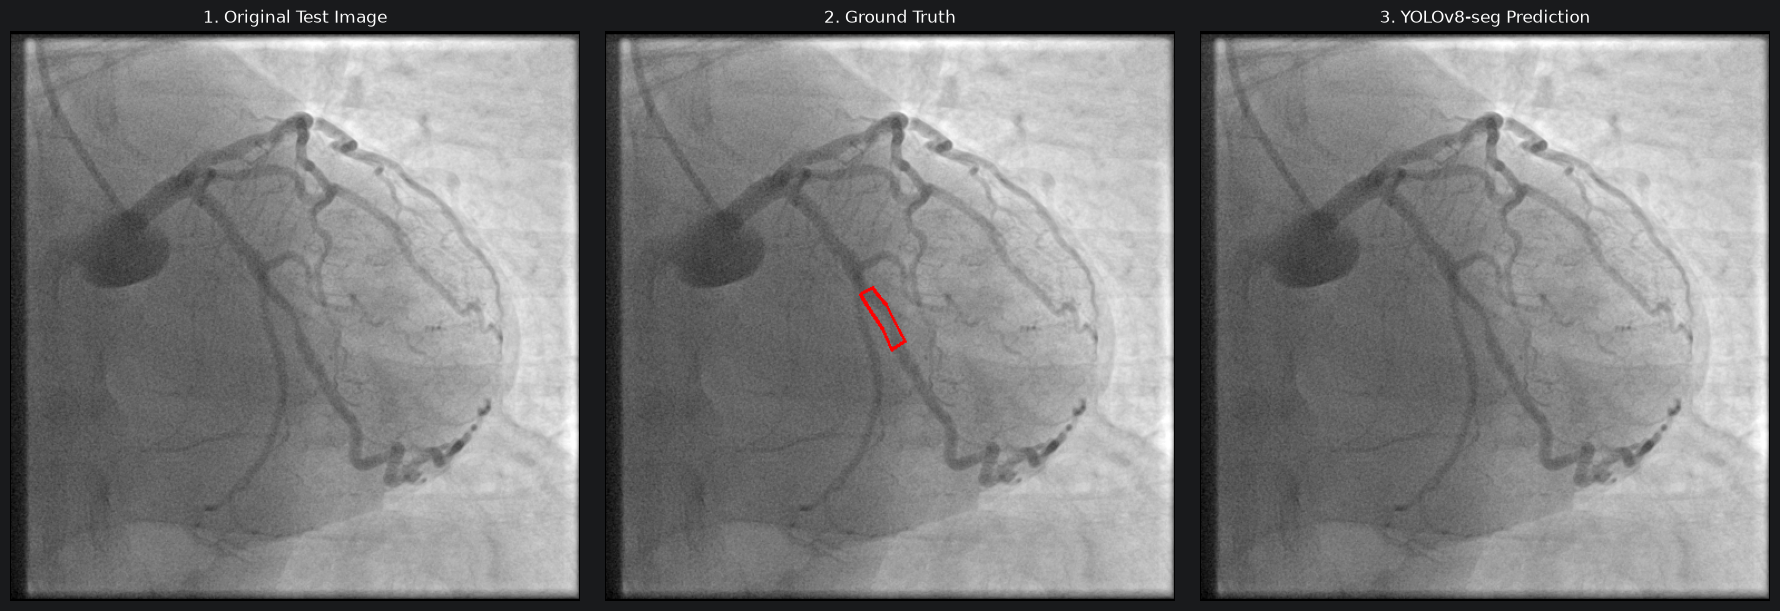

In [3]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ==========================================
# 1. Paths
# ==========================================

PROJECT_ROOT = Path(
    r"C:\Users\homsokhim\PycharmProjects\Health_analysis"
)

TEST_IMAGES = PROJECT_ROOT / "data/stenosis_yolo/images/test"
TEST_LABELS = PROJECT_ROOT / "data/stenosis_yolo/labels/test"

MODEL_PATH = PROJECT_ROOT / "runs/segment/train-2/weights/best.pt"

# ==========================================
# 2. Load trained model
# ==========================================

model = YOLO(str(MODEL_PATH))

print("Model loaded:")
print(MODEL_PATH)

# ==========================================
# 3. Find a test image that has Ground Truth
# ==========================================

selected_image = None

for image_path in sorted(TEST_IMAGES.glob("*")):

    if image_path.suffix.lower() not in [".png", ".jpg", ".jpeg"]:
        continue

    label_path = TEST_LABELS / f"{image_path.stem}.txt"

    if label_path.exists():

        with open(label_path, "r") as f:
            lines = [line.strip() for line in f if line.strip()]

        # Select an image with at least one stenosis annotation
        if len(lines) > 0:
            selected_image = image_path
            break

if selected_image is None:
    raise FileNotFoundError("Could not find a test image with Ground Truth.")

print("Selected image:")
print(selected_image)

# ==========================================
# 4. Read image
# ==========================================

image = cv2.imread(str(selected_image))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

print("Image size:", w, "x", h)

# ==========================================
# 5. Draw Ground Truth
# ==========================================

ground_truth = image.copy()

label_path = TEST_LABELS / f"{selected_image.stem}.txt"

with open(label_path, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

print("Ground Truth objects:", len(lines))

for line in lines:

    values = list(map(float, line.split()))

    # First value = class ID
    class_id = int(values[0])

    # Remaining values = x1 y1 x2 y2 ...
    coords = values[1:]

    points = []

    for i in range(0, len(coords), 2):

        x = int(coords[i] * w)
        y = int(coords[i + 1] * h)

        points.append([x, y])

    points = np.array(points, dtype=np.int32)

    cv2.polylines(
        ground_truth,
        [points],
        isClosed=True,
        color=(255, 0, 0),   # RED
        thickness=2
    )

# ==========================================
# 6. Run YOLO prediction
# ==========================================

results = model.predict(
    source=str(selected_image),
    imgsz=512,
    device=0,
    conf=0.25,
    verbose=False
)

result = results[0]

# ==========================================
# 7. Draw YOLO prediction
# ==========================================

prediction = image.copy()

if result.masks is not None:

    predicted_polygons = result.masks.xy

    print("Predicted objects:", len(predicted_polygons))

    for polygon in predicted_polygons:

        points = np.array(
            polygon,
            dtype=np.int32
        )

        cv2.polylines(
            prediction,
            [points],
            isClosed=True,
            color=(0, 255, 0),   # GREEN
            thickness=2
        )

else:

    print("Predicted objects: 0")

# ==========================================
# 8. Show three panels
# ==========================================

plt.figure(figsize=(18, 6))

plt.subplot(1, 3, 1)
plt.imshow(image)
plt.title("1. Original Test Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(ground_truth)
plt.title("2. Ground Truth")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(prediction)
plt.title("3. YOLOv8-seg Prediction")
plt.axis("off")

plt.tight_layout()
plt.show()

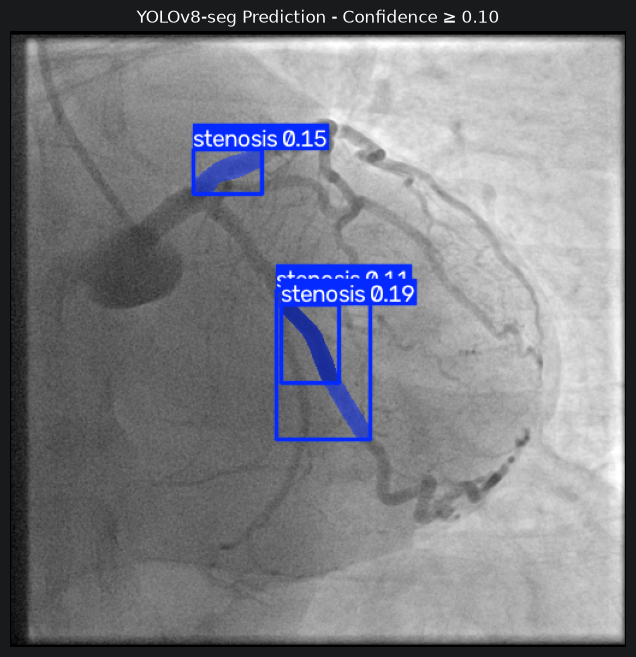

In [5]:
from ultralytics import YOLO
import matplotlib.pyplot as plt

model = YOLO(
    "runs/segment/train-2/weights/best.pt"
)

image_path = "data/stenosis_yolo/images/test/1.png"

results = model.predict(
    source=image_path,
    imgsz=512,
    device=0,
    conf=0.10,
    verbose=False
)

result = results[0]

# Plot YOLO's predictions
plt.figure(figsize=(10, 8))

if result.masks is not None:
    annotated = result.plot()

    # YOLO returns BGR, convert to RGB
    annotated = annotated[:, :, ::-1]

    plt.imshow(annotated)
    plt.title("YOLOv8-seg Prediction - Confidence ≥ 0.10")
else:
    plt.imshow(result.orig_img[:, :, ::-1])
    plt.title("No prediction")

plt.axis("off")
plt.show()

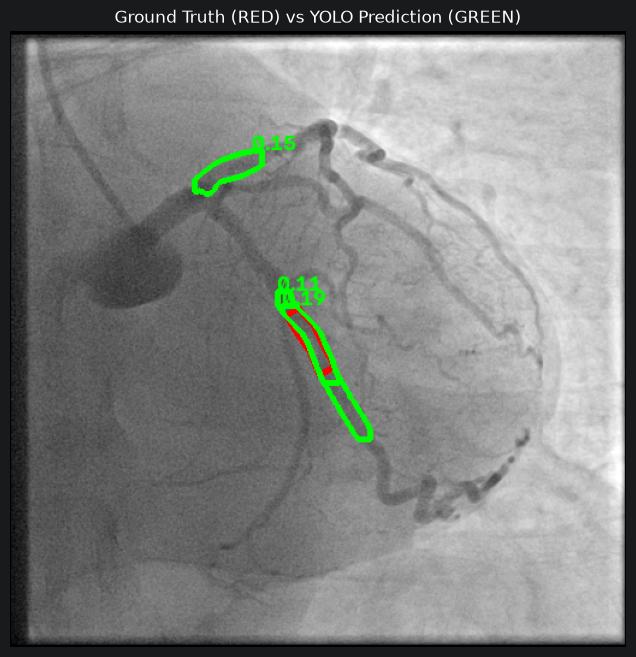

In [6]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

PROJECT_ROOT = Path(
    r"C:\Users\homsokhim\PycharmProjects\Health_analysis"
)

image_path = PROJECT_ROOT / "data/stenosis_yolo/images/test/1.png"
label_path = PROJECT_ROOT / "data/stenosis_yolo/labels/test/1.txt"
model_path = PROJECT_ROOT / "runs/segment/train-2/weights/best.pt"

# Load model
model = YOLO(str(model_path))

# Load image
image = cv2.imread(str(image_path))
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

h, w = image.shape[:2]

# ----------------------------------------
# Ground Truth
# ----------------------------------------

overlay = image.copy()

with open(label_path, "r") as f:
    lines = [line.strip() for line in f if line.strip()]

for line in lines:

    values = list(map(float, line.split()))
    coords = values[1:]

    points = []

    for i in range(0, len(coords), 2):
        x = int(coords[i] * w)
        y = int(coords[i + 1] * h)
        points.append([x, y])

    points = np.array(points, dtype=np.int32)

    # RED = Ground Truth
    cv2.polylines(
        overlay,
        [points],
        isClosed=True,
        color=(255, 0, 0),
        thickness=3
    )

# ----------------------------------------
# YOLO prediction
# ----------------------------------------

results = model.predict(
    source=str(image_path),
    imgsz=512,
    device=0,
    conf=0.10,
    verbose=False
)

result = results[0]

if result.masks is not None:

    for polygon, confidence in zip(
        result.masks.xy,
        result.boxes.conf.cpu().numpy()
    ):

        points = np.array(
            polygon,
            dtype=np.int32
        )

        # GREEN = Prediction
        cv2.polylines(
            overlay,
            [points],
            isClosed=True,
            color=(0, 255, 0),
            thickness=3
        )

        # Show confidence
        x, y = points[0]

        cv2.putText(
            overlay,
            f"{confidence:.2f}",
            (x, y),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.6,
            (0, 255, 0),
            2
        )

# ----------------------------------------
# Display
# ----------------------------------------

plt.figure(figsize=(10, 8))

plt.imshow(overlay)

plt.title(
    "Ground Truth (RED) vs YOLO Prediction (GREEN)"
)

plt.axis("off")
plt.show()

In [22]:
from pathlib import Path
import cv2
import csv
import numpy as np
from ultralytics import YOLO

# ============================================================
# 1. Paths
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\homsokhim\PycharmProjects\Health_analysis"
)
output_csv = (
    PROJECT_ROOT /
    "test_segmentation_metrics_conf030.csv"
)

MODEL_PATH = PROJECT_ROOT / "runs/segment/train-2/weights/best.pt"

TEST_IMAGES = PROJECT_ROOT / "data/stenosis_yolo/images/test"
TEST_LABELS = PROJECT_ROOT / "data/stenosis_yolo/labels/test"

# ============================================================
# 2. Settings
# ============================================================

CONF_THRESHOLD = 0.30
IMAGE_SIZE = 512

# ============================================================
# 3. Load model
# ============================================================

model = YOLO(str(MODEL_PATH))

print("Model loaded:")
print(MODEL_PATH)
print("Confidence threshold:", CONF_THRESHOLD)

# ============================================================
# 4. Get test images
# ============================================================

image_paths = sorted([
    p for p in TEST_IMAGES.iterdir()
    if p.suffix.lower() in [".png", ".jpg", ".jpeg"]
])

print("Test images:", len(image_paths))

# ============================================================
# 5. Function: Ground Truth mask
# ============================================================

def load_ground_truth(label_path, height, width):

    mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    if not label_path.exists():
        return mask

    with open(label_path, "r") as f:
        lines = [
            line.strip()
            for line in f
            if line.strip()
        ]

    for line in lines:

        values = list(map(float, line.split()))

        # First value = class ID
        coords = values[1:]

        if len(coords) < 6:
            continue

        points = []

        for i in range(0, len(coords), 2):

            x = int(coords[i] * width)
            y = int(coords[i + 1] * height)

            x = max(0, min(width - 1, x))
            y = max(0, min(height - 1, y))

            points.append([x, y])

        points = np.array(
            points,
            dtype=np.int32
        )

        cv2.fillPoly(
            mask,
            [points],
            1
        )

    return mask


# ============================================================
# 6. Metrics function
# ============================================================

def calculate_metrics(gt, pred):

    gt = gt.astype(bool)
    pred = pred.astype(bool)

    tp = np.logical_and(gt, pred).sum()
    fp = np.logical_and(~gt, pred).sum()
    fn = np.logical_and(gt, ~pred).sum()
    tn = np.logical_and(~gt, ~pred).sum()

    # Dice
    if (2 * tp + fp + fn) == 0:
        dice = 1.0
    else:
        dice = (2 * tp) / (2 * tp + fp + fn)

    # IoU
    if (tp + fp + fn) == 0:
        iou = 1.0
    else:
        iou = tp / (tp + fp + fn)

    # Precision
    if (tp + fp) == 0:
        precision = 0.0
    else:
        precision = tp / (tp + fp)

    # Recall
    if (tp + fn) == 0:
        recall = 0.0
    else:
        recall = tp / (tp + fn)

    # F1
    if (2 * tp + fp + fn) == 0:
        f1 = 1.0
    else:
        f1 = (2 * tp) / (2 * tp + fp + fn)

    return {
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "Dice": dice,
        "IoU": iou,
        "Precision": precision,
        "Recall": recall,
        "F1": f1
    }


# ============================================================
# 7. Evaluate all test images
# ============================================================

results_table = []

for index, image_path in enumerate(image_paths):

    # --------------------------------------------
    # Read image
    # --------------------------------------------

    image = cv2.imread(str(image_path))

    if image is None:
        print("Could not read:", image_path)
        continue

    height, width = image.shape[:2]

    # --------------------------------------------
    # Ground Truth
    # --------------------------------------------

    label_path = TEST_LABELS / f"{image_path.stem}.txt"

    gt_mask = load_ground_truth(
        label_path,
        height,
        width
    )

    # --------------------------------------------
    # YOLO prediction
    # --------------------------------------------

    prediction_results = model.predict(
        source=str(image_path),
        imgsz=IMAGE_SIZE,
        conf=CONF_THRESHOLD,
        device=0,
        verbose=False
    )

    result = prediction_results[0]

    # Empty prediction mask
    pred_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    num_predictions = 0
    max_confidence = 0.0

    # --------------------------------------------
    # Get segmentation masks
    # --------------------------------------------

    if result.masks is not None:

        num_predictions = len(result.masks.data)

        # YOLO mask tensor
        masks = result.masks.data.cpu().numpy()

        # Union all predicted masks
        for mask in masks:

            mask = (mask > 0.5).astype(np.uint8)

            # Resize if necessary
            if mask.shape != (height, width):

                mask = cv2.resize(
                    mask,
                    (width, height),
                    interpolation=cv2.INTER_NEAREST
                )

            pred_mask = np.maximum(
                pred_mask,
                mask
            )

        if result.boxes is not None and len(result.boxes.conf) > 0:

            max_confidence = float(
                result.boxes.conf.max().cpu().item()
            )

    # --------------------------------------------
    # Calculate metrics
    # --------------------------------------------

    metrics = calculate_metrics(
        gt_mask,
        pred_mask
    )

    # --------------------------------------------
    # Additional information
    # --------------------------------------------

    gt_pixels = int(gt_mask.sum())
    pred_pixels = int(pred_mask.sum())

    gt_has_stenosis = gt_pixels > 0
    pred_has_stenosis = pred_pixels > 0

    results_table.append({

        "image": image_path.name,

        "GT_pixels": gt_pixels,
        "Pred_pixels": pred_pixels,

        "GT_has_stenosis": gt_has_stenosis,
        "Pred_has_stenosis": pred_has_stenosis,

        "Num_predictions": num_predictions,
        "Max_confidence": max_confidence,

        **metrics
    })

    # Progress
    if (index + 1) % 10 == 0:
        print(
            f"Processed {index + 1}/{len(image_paths)} images"
        )

# ============================================================
# 8. Calculate average metrics
# ============================================================

print("\n========================================")
print("TEST SET EVALUATION COMPLETE")
print("========================================")

print("Images evaluated:", len(results_table))

# ------------------------------------------------------------
# Average metrics
# ------------------------------------------------------------

metrics_names = [
    "Dice",
    "IoU",
    "Precision",
    "Recall",
    "F1"
]

print("\nAverage metrics:")
print("----------------------------------------")

for metric in metrics_names:

    values = [
        row[metric]
        for row in results_table
    ]

    average = np.mean(values)

    print(
        f"{metric:10s}: {average:.4f}"
    )

# ============================================================
# 9. Image-level summary
# ============================================================

gt_positive = sum(
    row["GT_has_stenosis"]
    for row in results_table
)

pred_positive = sum(
    row["Pred_has_stenosis"]
    for row in results_table
)

missed = sum(
    row["GT_has_stenosis"] and
    not row["Pred_has_stenosis"]
    for row in results_table
)

false_positive_images = sum(
    not row["GT_has_stenosis"] and
    row["Pred_has_stenosis"]
    for row in results_table
)

correct_positive = sum(
    row["GT_has_stenosis"] and
    row["Pred_has_stenosis"]
    for row in results_table
)

print("\nImage-level summary:")
print("----------------------------------------")

print(
    "Images with Ground Truth stenosis:",
    gt_positive
)

print(
    "Images with YOLO prediction:",
    pred_positive
)

print(
    "GT stenosis images missed:",
    missed
)

print(
    "False-positive images:",
    false_positive_images
)

print(
    "GT positive + prediction:",
    correct_positive
)

# ============================================================
# 10. Save results as CSV
# ============================================================

fieldnames = list(results_table[0].keys())

with open(
    output_csv,
    "w",
    newline="",
    encoding="utf-8"
) as f:

    writer = csv.DictWriter(
        f,
        fieldnames=fieldnames
    )

    writer.writeheader()
    writer.writerows(results_table)

print("\nResults saved to:")
print(output_csv)

Model loaded:
C:\Users\homsokhim\PycharmProjects\Health_analysis\runs\segment\train-2\weights\best.pt
Confidence threshold: 0.3
Test images: 300
Processed 10/300 images
Processed 20/300 images
Processed 30/300 images
Processed 40/300 images
Processed 50/300 images
Processed 60/300 images
Processed 70/300 images
Processed 80/300 images
Processed 90/300 images
Processed 100/300 images
Processed 110/300 images
Processed 120/300 images
Processed 130/300 images
Processed 140/300 images
Processed 150/300 images
Processed 160/300 images
Processed 170/300 images
Processed 180/300 images
Processed 190/300 images
Processed 200/300 images
Processed 210/300 images
Processed 220/300 images
Processed 230/300 images
Processed 240/300 images
Processed 250/300 images
Processed 260/300 images
Processed 270/300 images
Processed 280/300 images
Processed 290/300 images
Processed 300/300 images

TEST SET EVALUATION COMPLETE
Images evaluated: 300

Average metrics:
----------------------------------------
Dic

In [23]:
import csv
from pathlib import Path

PROJECT_ROOT = Path(
    r"C:\Users\homsokhim\PycharmProjects\Health_analysis"
)

CSV_PATH = PROJECT_ROOT / "test_segmentation_metrics_conf010.csv"

# Read CSV
with open(CSV_PATH, "r", encoding="utf-8") as f:
    reader = csv.DictReader(f)
    rows = list(reader)

# Convert numbers
for row in rows:
    row["Dice"] = float(row["Dice"])
    row["IoU"] = float(row["IoU"])
    row["Precision"] = float(row["Precision"])
    row["Recall"] = float(row["Recall"])
    row["F1"] = float(row["F1"])
    row["Num_predictions"] = int(row["Num_predictions"])
    row["Max_confidence"] = float(row["Max_confidence"])

# Sort by Dice
best = sorted(
    rows,
    key=lambda x: x["Dice"],
    reverse=True
)

worst = sorted(
    rows,
    key=lambda x: x["Dice"]
)

# Missed stenosis
missed = [
    row for row in rows
    if row["GT_has_stenosis"] == "True"
    and row["Pred_has_stenosis"] == "False"
]

print("====================================")
print("BEST 5")
print("====================================")

for row in best[:5]:
    print(
        row["image"],
        "Dice =", round(row["Dice"], 4),
        "IoU =", round(row["IoU"], 4),
        "Confidence =", round(row["Max_confidence"], 4)
    )

print("\n====================================")
print("WORST 5")
print("====================================")

for row in worst[:5]:
    print(
        row["image"],
        "Dice =", round(row["Dice"], 4),
        "IoU =", round(row["IoU"], 4),
        "Confidence =", round(row["Max_confidence"], 4)
    )

print("\n====================================")
print("MISSED STENOSIS")
print("====================================")

print("Number missed:", len(missed))

for row in missed[:20]:
    print(
        row["image"],
        "Dice =", round(row["Dice"], 4),
        "Predictions =", row["Num_predictions"]
    )

BEST 5
101.png Dice = 0.9123 IoU = 0.8387 Confidence = 0.5535
157.png Dice = 0.9086 IoU = 0.8326 Confidence = 0.218
64.png Dice = 0.9004 IoU = 0.8188 Confidence = 0.2606
130.png Dice = 0.8974 IoU = 0.8139 Confidence = 0.4427
99.png Dice = 0.8894 IoU = 0.8009 Confidence = 0.1959

WORST 5
10.png Dice = 0.0 IoU = 0.0 Confidence = 0.1008
113.png Dice = 0.0 IoU = 0.0 Confidence = 0.0
115.png Dice = 0.0 IoU = 0.0 Confidence = 0.0
118.png Dice = 0.0 IoU = 0.0 Confidence = 0.0
119.png Dice = 0.0 IoU = 0.0 Confidence = 0.0

MISSED STENOSIS
Number missed: 27
113.png Dice = 0.0 Predictions = 0
115.png Dice = 0.0 Predictions = 0
118.png Dice = 0.0 Predictions = 0
119.png Dice = 0.0 Predictions = 0
131.png Dice = 0.0 Predictions = 0
134.png Dice = 0.0 Predictions = 0
163.png Dice = 0.0 Predictions = 0
165.png Dice = 0.0 Predictions = 0
167.png Dice = 0.0 Predictions = 0
180.png Dice = 0.0 Predictions = 0
184.png Dice = 0.0 Predictions = 0
193.png Dice = 0.0 Predictions = 0
236.png Dice = 0.0 Predic


BEST CASE


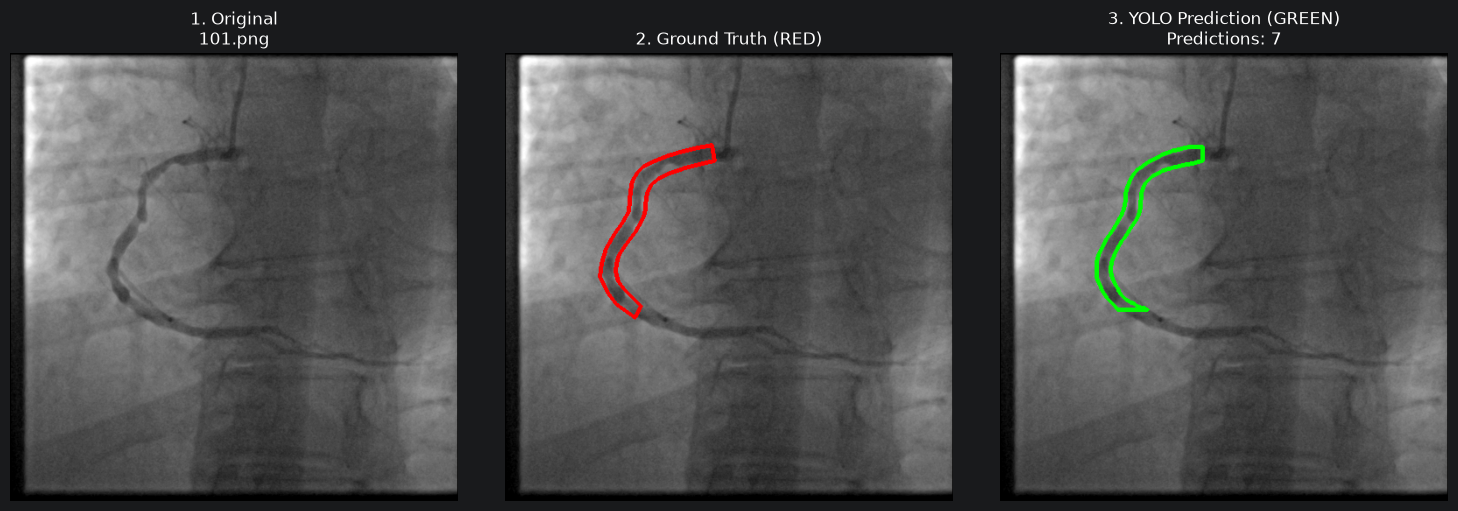

----------------------------------------
Image: 101.png
Ground Truth pixels: 5010
Prediction pixels: 4474
Number of predictions: 7
Confidence: [0.5535381436347961, 0.3363713026046753, 0.19237735867500305, 0.18475422263145447, 0.14612038433551788, 0.140158012509346, 0.13515424728393555]

WORST CASE


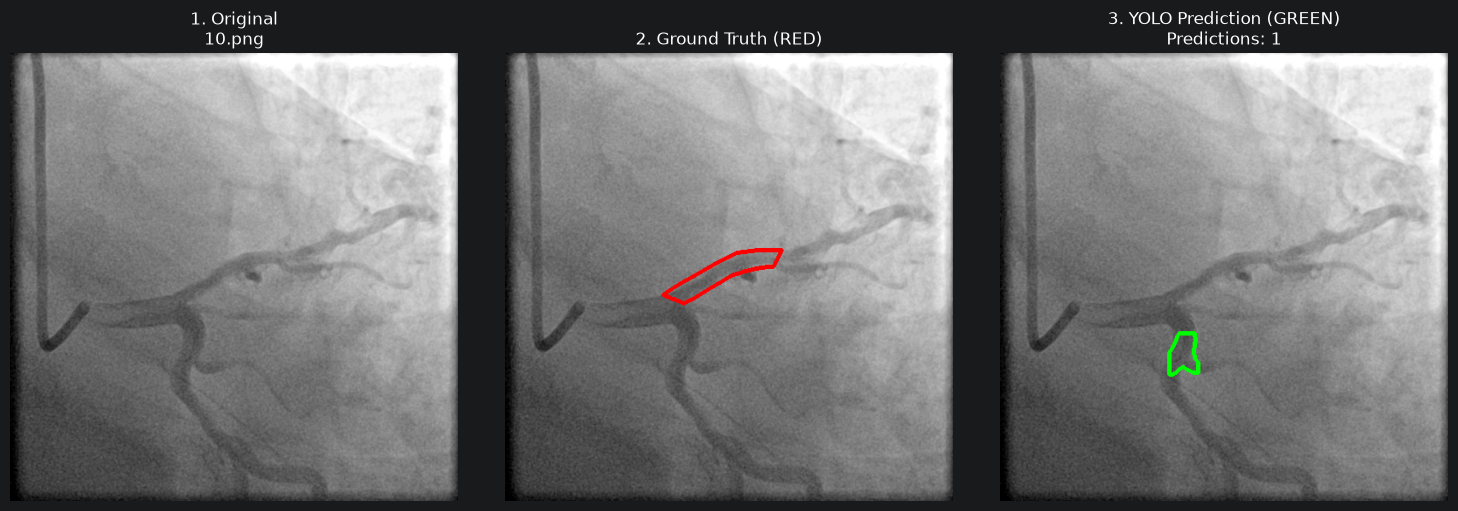

----------------------------------------
Image: 10.png
Ground Truth pixels: 2900
Prediction pixels: 1243
Number of predictions: 1
Confidence: [0.10080468654632568]

MISSED CASE


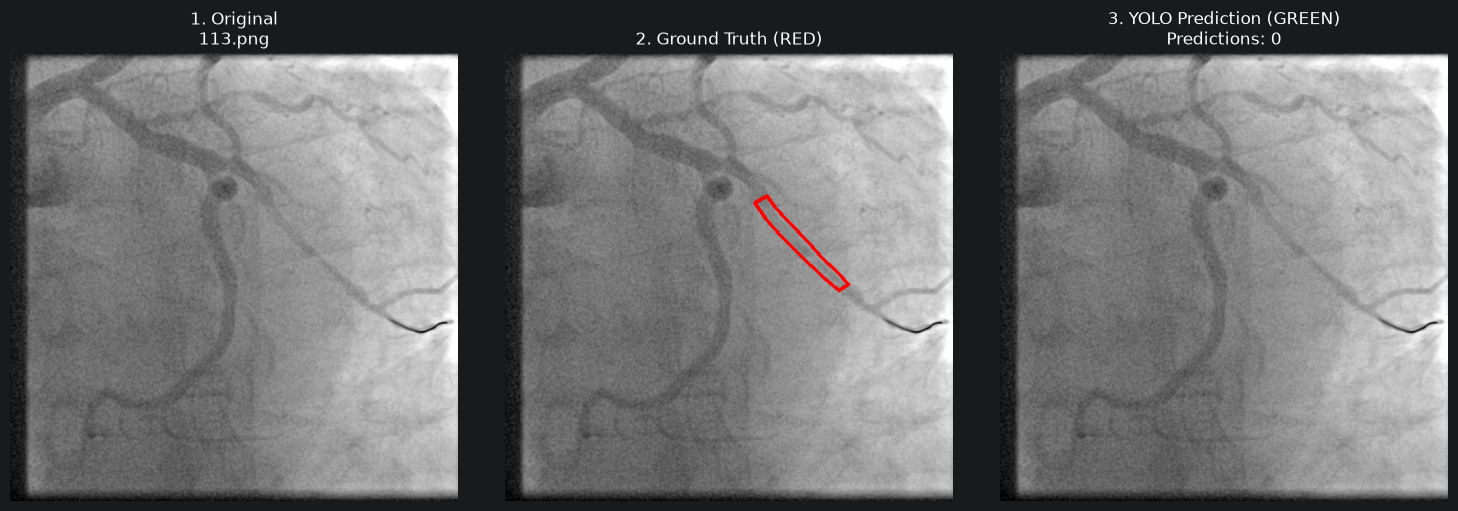

----------------------------------------
Image: 113.png
Ground Truth pixels: 2340
Prediction pixels: 0
Number of predictions: 0
Confidence: []


In [24]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt
from ultralytics import YOLO

# ============================================================
# Paths
# ============================================================

PROJECT_ROOT = Path(
    r"C:\Users\homsokhim\PycharmProjects\Health_analysis"
)

MODEL_PATH = (
    PROJECT_ROOT /
    "runs/segment/train-2/weights/best.pt"
)

IMAGE_DIR = (
    PROJECT_ROOT /
    "data/stenosis_yolo/images/test"
)

LABEL_DIR = (
    PROJECT_ROOT /
    "data/stenosis_yolo/labels/test"
)

# ============================================================
# Load model
# ============================================================

model = YOLO(str(MODEL_PATH))

# ============================================================
# Function to create visualization
# ============================================================

def visualize_case(filename, conf=0.10):

    image_path = IMAGE_DIR / filename
    label_path = LABEL_DIR / filename.replace(".png", ".txt")

    # -----------------------------------------
    # Load image
    # -----------------------------------------

    image_bgr = cv2.imread(str(image_path))

    if image_bgr is None:
        print("Cannot read:", image_path)
        return

    image = cv2.cvtColor(
        image_bgr,
        cv2.COLOR_BGR2RGB
    )

    height, width = image.shape[:2]

    # -----------------------------------------
    # Ground Truth mask
    # -----------------------------------------

    gt_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    if label_path.exists():

        with open(label_path, "r") as f:

            lines = [
                line.strip()
                for line in f
                if line.strip()
            ]

        for line in lines:

            values = list(
                map(float, line.split())
            )

            coords = values[1:]

            if len(coords) < 6:
                continue

            points = []

            for i in range(0, len(coords), 2):

                x = int(coords[i] * width)
                y = int(coords[i + 1] * height)

                x = max(0, min(width - 1, x))
                y = max(0, min(height - 1, y))

                points.append([x, y])

            points = np.array(
                points,
                dtype=np.int32
            )

            cv2.fillPoly(
                gt_mask,
                [points],
                1
            )

    # -----------------------------------------
    # YOLO prediction
    # -----------------------------------------

    results = model.predict(
        source=str(image_path),
        imgsz=512,
        conf=conf,
        device=0,
        verbose=False
    )

    result = results[0]

    pred_mask = np.zeros(
        (height, width),
        dtype=np.uint8
    )

    confidences = []

    if result.masks is not None:

        masks = result.masks.data.cpu().numpy()

        for i, mask in enumerate(masks):

            mask = (mask > 0.5).astype(np.uint8)

            if mask.shape != (height, width):

                mask = cv2.resize(
                    mask,
                    (width, height),
                    interpolation=cv2.INTER_NEAREST
                )

            pred_mask = np.maximum(
                pred_mask,
                mask
            )

            if result.boxes is not None:
                confidences.append(
                    float(
                        result.boxes.conf[i]
                        .cpu()
                        .item()
                    )
                )

    # -----------------------------------------
    # Create Ground Truth visualization
    # -----------------------------------------

    gt_image = image.copy()

    contours_gt, _ = cv2.findContours(
        gt_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        gt_image,
        contours_gt,
        -1,
        (255, 0, 0),
        3
    )

    # -----------------------------------------
    # Create Prediction visualization
    # -----------------------------------------

    pred_image = image.copy()

    contours_pred, _ = cv2.findContours(
        pred_mask,
        cv2.RETR_EXTERNAL,
        cv2.CHAIN_APPROX_SIMPLE
    )

    cv2.drawContours(
        pred_image,
        contours_pred,
        -1,
        (0, 255, 0),
        3
    )

    # -----------------------------------------
    # Display
    # -----------------------------------------

    fig, axes = plt.subplots(
        1,
        3,
        figsize=(15, 5)
    )

    axes[0].imshow(image)
    axes[0].set_title(
        f"1. Original\n{filename}"
    )
    axes[0].axis("off")

    axes[1].imshow(gt_image)
    axes[1].set_title(
        "2. Ground Truth (RED)"
    )
    axes[1].axis("off")

    axes[2].imshow(pred_image)
    axes[2].set_title(
        f"3. YOLO Prediction (GREEN)\n"
        f"Predictions: {len(confidences)}"
    )
    axes[2].axis("off")

    plt.tight_layout()
    plt.show()

    print("----------------------------------------")
    print("Image:", filename)
    print("Ground Truth pixels:", int(gt_mask.sum()))
    print("Prediction pixels:", int(pred_mask.sum()))
    print("Number of predictions:", len(confidences))
    print("Confidence:", confidences)


# ============================================================
# 1. BEST CASE
# ============================================================

print("\nBEST CASE")
visualize_case("101.png")


# ============================================================
# 2. WORST CASE WITH PREDICTION
# ============================================================

print("\nWORST CASE")
visualize_case("10.png")


# ============================================================
# 3. MISSED CASE
# ============================================================

print("\nMISSED CASE")
visualize_case("113.png")